# Sampling Basics 

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()

import control_materials as cm
print("Control Material version:", cm.__version__)
cm.setup_environment()


Basic Material version: 16.002-0.1


Control Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import control as ct
import control.matlab as cmat

from scipy import signal
from scipy.fftpack import fft, ifft, fftfreq, fftshift

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
# Function to plot the aliasing effect in the frequency domain
def alias_plot(data):
    f1,f1_alias, t, ts, x, x0, x0_alias = data
    Ts = ts[1] - ts[0]  # Sampling interval
    fs = 1 / Ts  # Sampling frequency
    freq = fftfreq(len(t), t[1] - t[0])  # Frequency bins for continuous signal
    freq_s = fftfreq(len(ts), Ts)  # Frequency bins for sampled signal

    X = fft(x)  # FFT of continuous signal
    X0 = fft(x0)  # FFT of sampled signal
    X0_alias = fft(x0_alias)  # FFT of aliased signal
    
    II_X = np.argmax(X)  # Index of max frequency component in continuous signal
    II_X0 = np.argmax(X0)  # Index of max frequency component in sampled signal
    II_X0_alias = np.argmax(X0_alias)  # Index of max frequency component in aliased signal
    
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.axvline(x=freq[II_X], color="r", lw=6, label="$f_1=$" + str(f1))  # Original frequency
    ax.axvline(x=-freq[II_X], color="r", lw=6)
    ax.axvline(x=freq[II_X0_alias], color="b", lw=4, ls="dashed", label="$f_1\,'=$" + str(np.round(f1_alias, 3)))  # Aliased frequency
    ax.axvline(x=-freq[II_X0_alias], color="b", lw=4, ls="dashed")
    ax.axvline(x=freq_s[II_X0], color="g", label="sampled")  # Sampled frequency
    ax.axvline(x=-freq_s[II_X0], color="g")
    ax.axvline(x=fs / 2, color="k", ls="dashed", ymax=0.75)  # Nyquist frequency
    ax.axvline(x=-fs / 2, color="k", ls="dashed", ymax=0.75)
    ax.axvline(x=fs, color="k", ymax=0.75)  # Sampling frequency
    ax.axvline(x=-fs, color="k", ymax=0.75)
    ax.axvline(x=2 * fs, color="k", ymax=0.75)  # Twice the sampling frequency
    ax.axvline(x=-2 * fs, color="k", ymax=0.75)
    ax.set_xlim([-1.5, 1.5])
    ax.set_xticks([-2 * fs, -fs, -fs / 2, fs / 2, fs, 2 * fs], ["$-2f_s$", "$-f_s$", "$-f_s/2$", "$f_s/2$", "$f_s$", "$2f_s$"])
 
    rect = plt.Rectangle((-fs / 2, 0), fs, 1, alpha=0.4, color="grey")
    ax.add_patch(rect)

    ax.legend()
    plt.title("Alias mapping with $f_s=$" + str(fs))
    plt.show()

# Function to plot the time domain representation of the signals
def time_plot(data, filename, Tf=10):
    f1,f1_alias, t, ts, x, x0, x0_alias = data
    Ts = ts[1] - ts[0]  # Sampling interval
    fs = 1 / Ts  # Sampling frequency
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t, x, 'k--', lw=1, label='cts signal')  # Continuous signal
    ax.plot(ts, x0, 'ro', label='samples')  # Sampled signal
    ax.plot(t, x0_alias, 'b:', lw=2, label='aliased signal')  # Aliased signal
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlim(0, Tf - 1)
    ax.set_xlabel('time', fontsize=18)
    ax.set_ylabel('amplitude', fontsize=18)
    plt.title('Sampled Data')
    msg = '$f_1=$' + str(f1) + "Hz and $f_1\,'=$" + str(np.round(f1_alias, 3)) + 'Hz'
    if f1_alias >= 0: 
        plt.title(msg, loc='left', color='k')
    else:
        plt.title(msg, loc='left', color='r')
    plt.title('Sampling Frequency $f_s=$' + str(fs) + 'Hz', loc='right', color='g')
    plt.legend(loc=1)
    fig.savefig(filename, format='pdf', dpi=300)
    plt.show()

# Function to set up the aliasing example
def alias_setup(Tf=10, Ts=1, f1=3/8):
    dt_small = 1e-3 # Small time step 
    fs = 1 / Ts  # Sampling frequency
    t = np.arange(0, Tf, dt_small)  # Continuous time vector
    ts = np.arange(0, Tf, Ts)  # Sampled time vector

    w0 = 2 * np.pi * f1  # Angular frequency
    x = np.sin(w0 * t)  # Continuous signal
    x0 = np.sin(w0 * ts)  # Sampled signal
    f1_alias = f1 - fs * np.round(f1 / fs, 0)  # Aliased frequency
    x0_alias = np.sin(2 * np.pi * f1_alias * t)  # Aliased signal
    return f1,f1_alias, t, ts, x, x0, x0_alias

In [5]:
x = np.arange(0, 5, .5)
print(x)
print(np.round(x,0))

[   0.000    0.500    1.000    1.500    2.000    2.500    3.000    3.500
    4.000    4.500]
[   0.000    0.000    1.000    2.000    2.000    2.000    3.000    4.000
    4.000    4.000]


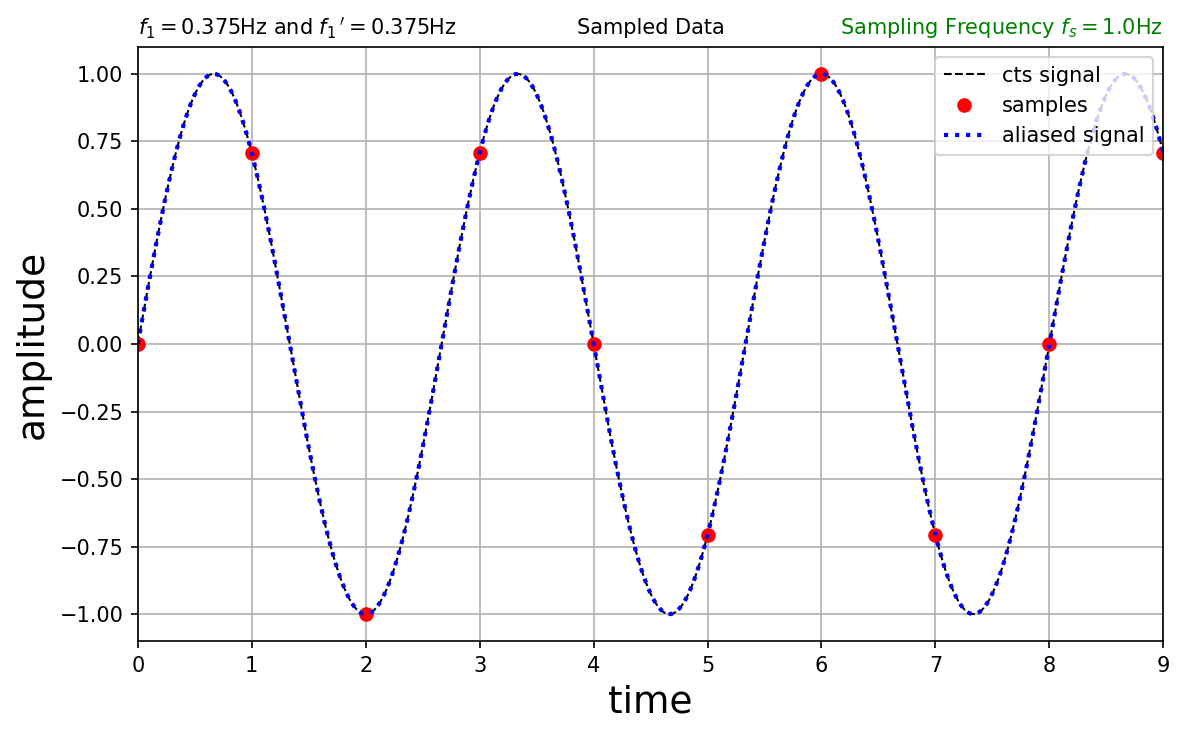

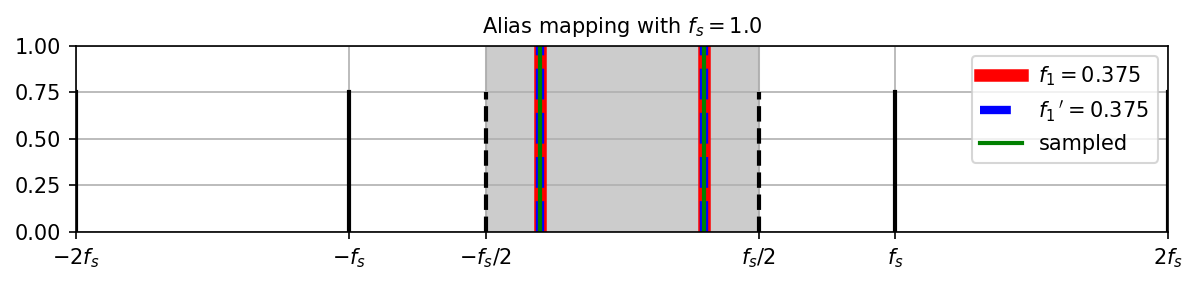

In [6]:
Ts = 1
f1 = 3/8
data = alias_setup(Ts=Ts,f1=f1)
time_plot(data,"./figs/T9_ex1.pdf")
alias_plot(data)

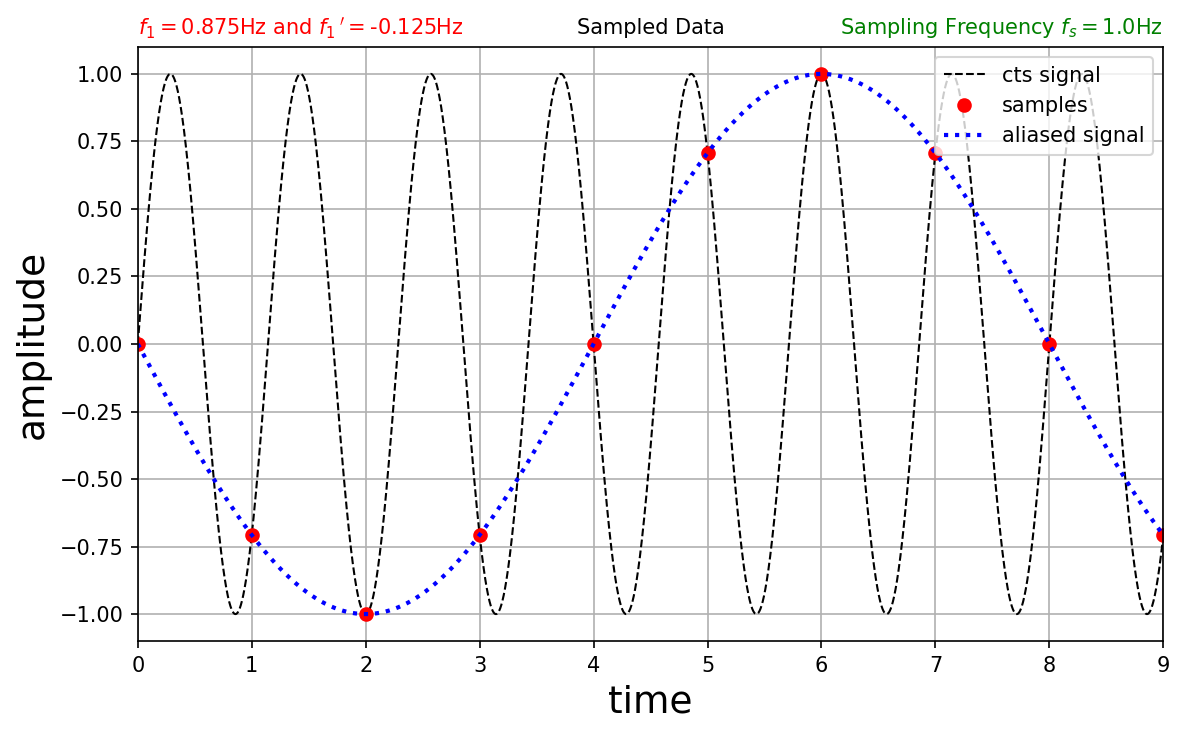

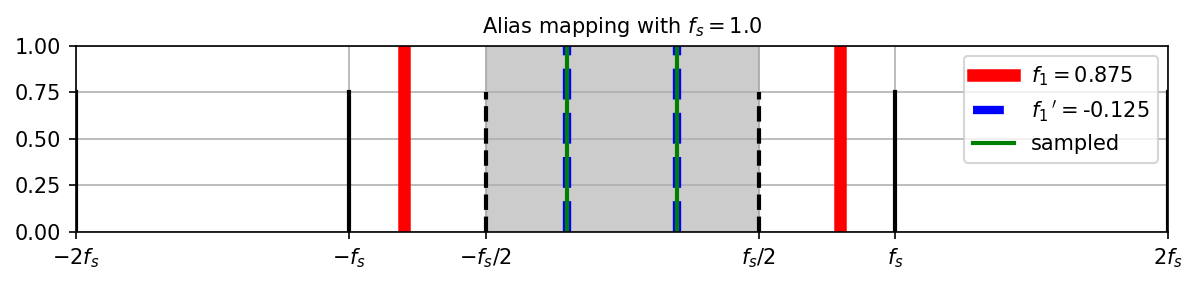

In [7]:
Ts = 1
f1 = 7/8
data = alias_setup(Tf=10,Ts=Ts,f1=f1)
time_plot(data,"./figs/T9_ex2.pdf")
alias_plot(data)

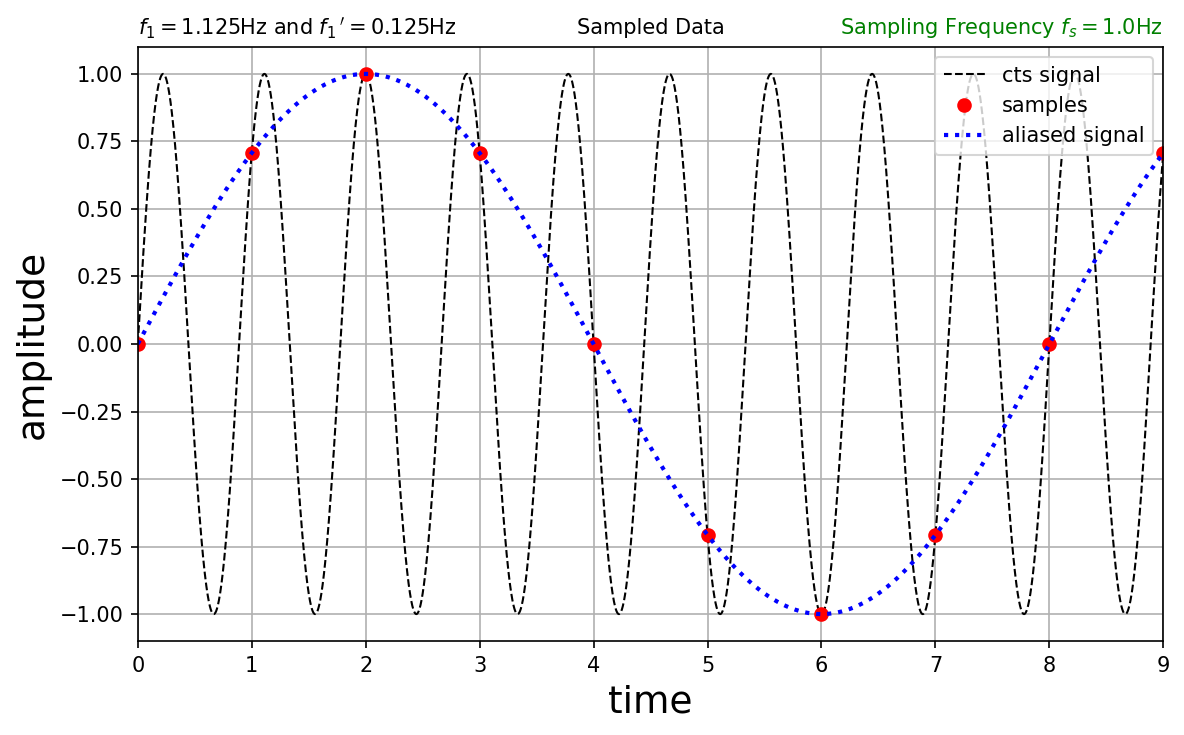

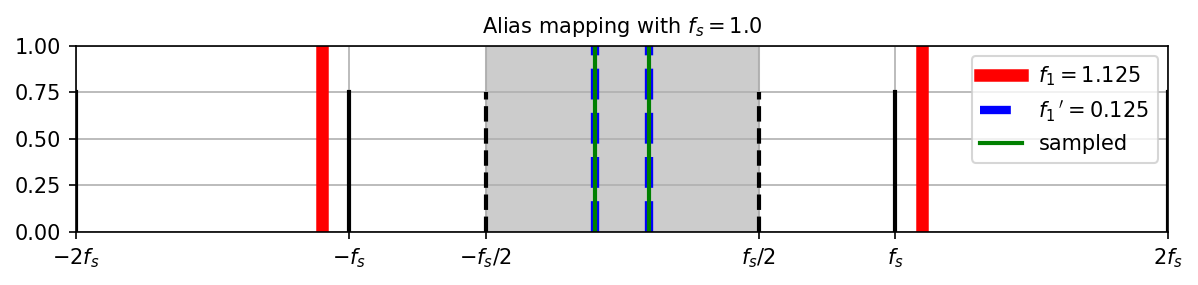

In [8]:
Ts = 1
f1 = 9/8
data = alias_setup(Tf=10,Ts=Ts,f1=f1)
time_plot(data,"./figs/T9_ex3.pdf")
alias_plot(data)

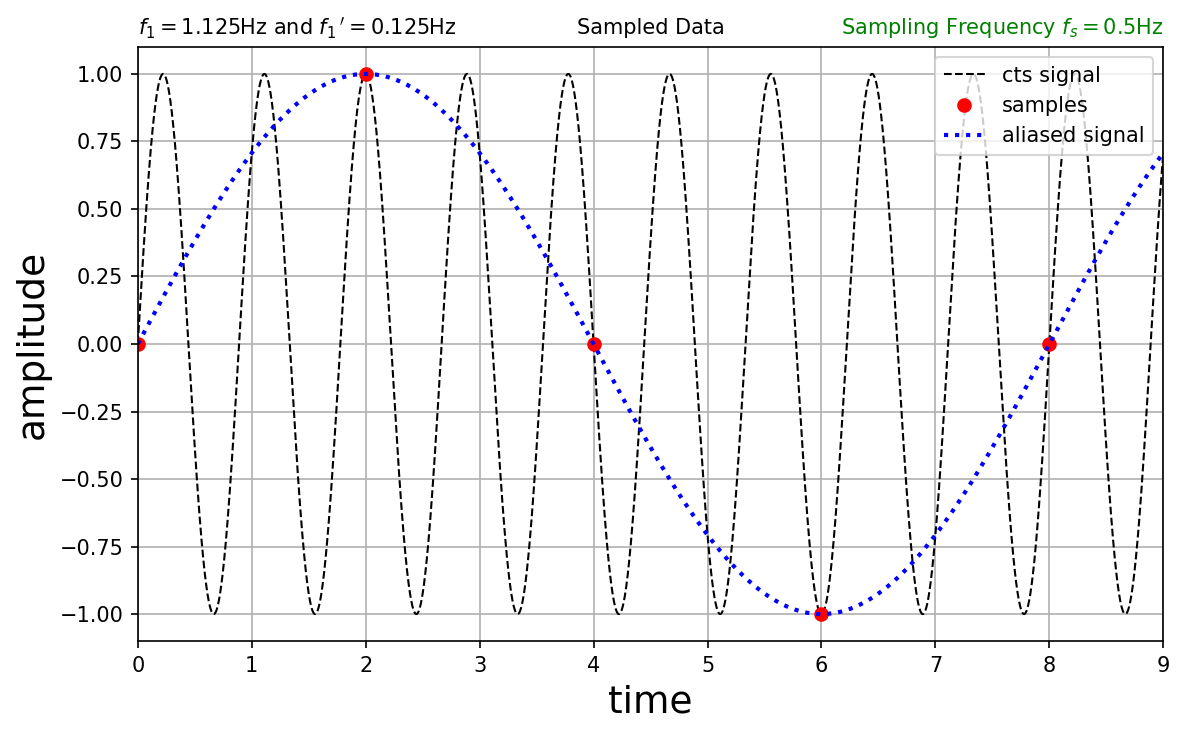

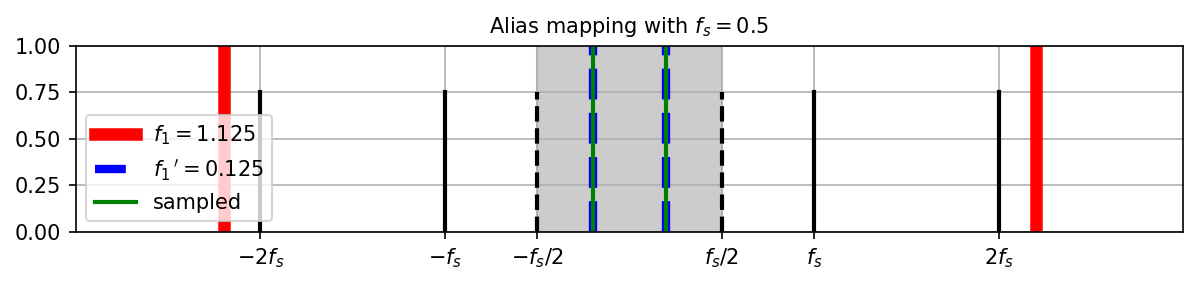

In [9]:
Ts = 2
f1 = 9/8
data = alias_setup(Tf=10,Ts=Ts,f1=f1)
time_plot(data,"./figs/T9_ex4.pdf")
alias_plot(data)

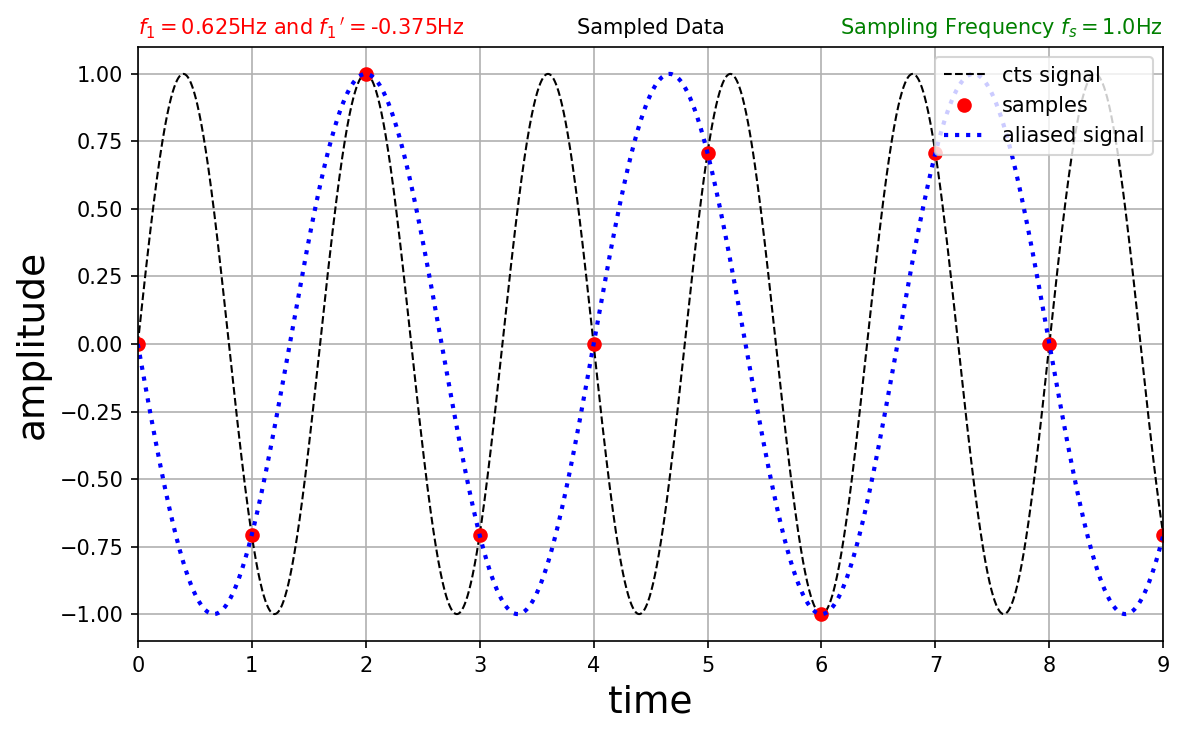

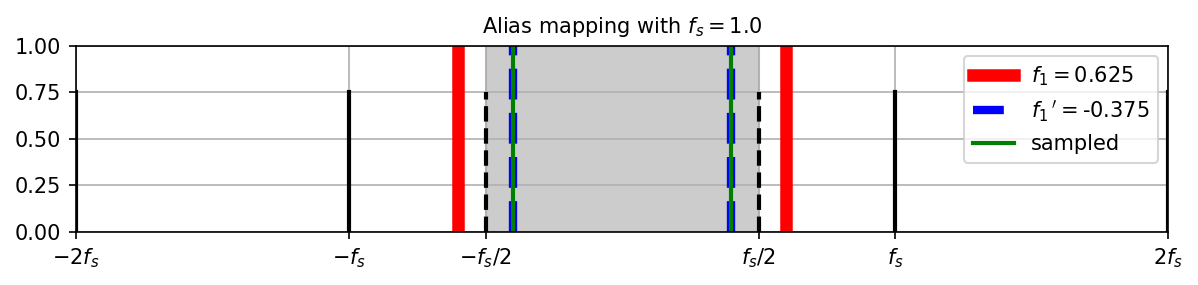

In [10]:
# Define parameters for the sine function
Ts = 1
f1 = 5/8  # Change this value to see different aliasing effects

# Generate the aliasing setup
data = alias_setup(Tf=10, Ts=Ts, f1=f1)

# Plot the time domain representation
time_plot(data, "./figs/T9_ex_aliasing.pdf")

# Plot the frequency domain representation
alias_plot(data)

In [11]:
1*np.round(75/100)

1.0

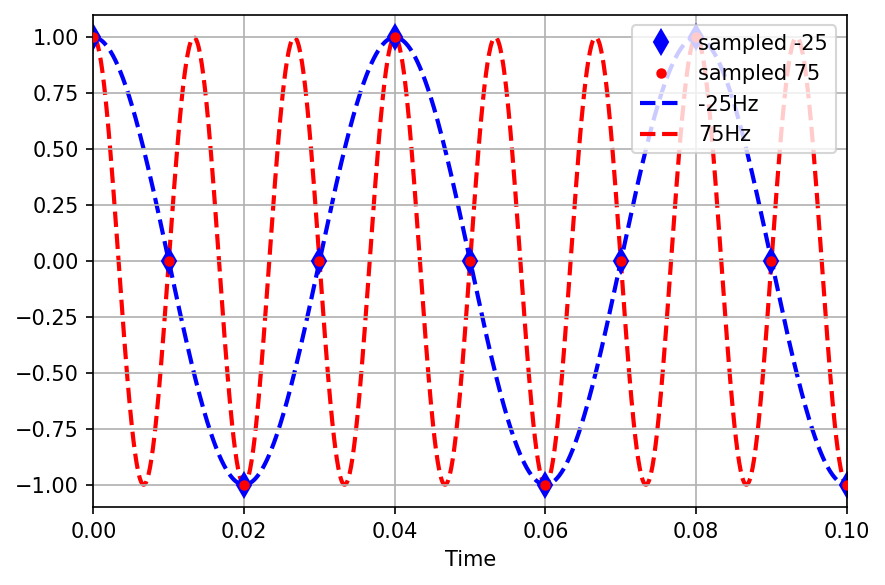

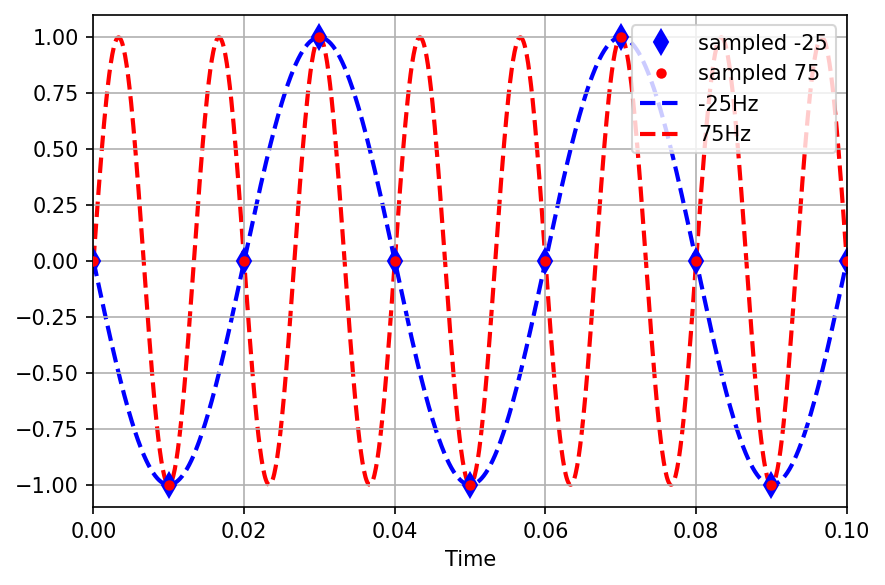

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(1)
plt.clf()
plt.gcf().set_size_inches(6, 4)
fs = 100
t = np.arange(0, 11) / fs
tdense = np.arange(0, max(t), 0.0001)

x25 = np.cos(-2 * np.pi * 25 * t)
x75 = np.cos(2 * np.pi * 75 * t)
plt.plot(t, x25, 'bd', markerfacecolor='b', markersize=8, label='sampled -25',zorder=2)
plt.plot(t, x75, 'ro', markerfacecolor='r', markersize=4, label='sampled 75',zorder=3)
plt.plot(tdense, np.cos(-2 * np.pi * 25 * tdense), 'b--', label='-25Hz',zorder=1)
plt.plot(tdense, np.cos(2 * np.pi * 75 * tdense), 'r--', label='75Hz',zorder=1)

plt.legend(loc='upper right')
plt.xlabel('Time')
plt.savefig('figs/folding.pdf', dpi=300)

plt.figure(2)
plt.gcf().set_size_inches(6, 4)
x25 = np.sin(-2 * np.pi * 25 * t)
x75 = np.sin(2 * np.pi * 75 * t)

plt.plot(t, x25, 'bd', markerfacecolor='b', markersize=8, label='sampled -25',zorder=2)
plt.plot(t, x75, 'ro', markerfacecolor='r', markersize=4, label='sampled 75',zorder=3)
plt.plot(tdense, np.sin(-2 * np.pi * 25 * tdense), 'b--', label='-25Hz',zorder=1)
plt.plot(tdense, np.sin(2 * np.pi * 75 * tdense), 'r--', label='75Hz',zorder=1)

plt.legend(loc='upper right')
plt.xlabel('Time')
plt.savefig('figs/folding2.pdf', dpi=300)


In [13]:
np.round(27/30)

1.0

In [14]:
np.roots([1, 7, 13, 8, 5, 10, 16])

array([-4.43440174+0.j        , -2.        +0.j        ,
       -0.90735156+0.93266414j, -0.90735156-0.93266414j,
        0.62455243+0.82185741j,  0.62455243-0.82185741j])